<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%203/week3_logreg_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — Logistic Regression From Scratch (Titanic)

**Goal:** Build a complete logistic regression classifier using only NumPy, and train it to predict Titanic survival with >78% accuracy.

This ties together everything from the week:
- **Conditional probability** (the survival patterns we explored)
- **Sigmoid + cross-entropy** (the math we derived)
- **The `(p - y)` gradient** (the clean result we proved numerically)
- **Gradient descent** (the training loop from micrograd)

### The pipeline

| Stage | What happens |
|---|---|
| 1. Load | Read the Titanic dataset |
| 2. Clean | Fill missing ages, drop empty columns |
| 3. Encode | Turn categories (sex, embarked) into numbers |
| 4. Scale | Standardize age and fare to mean 0, std 1 |
| 5. Split | 80% train / 20% test |
| 6. Train | Gradient descent with the `(p-y)` gradient |
| 7. Evaluate | Accuracy + inspect learned weights |

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

---
## 1-2. Load and Clean

Two cleaning steps before anything else:
- **Drop `deck`** — 688 of 891 values are missing, too sparse to be useful.
- **Fill `age`** — 177 missing values, filled with the median (robust to outliers, unlike the mean).

In [11]:
df = sns.load_dataset("titanic")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Drop the mostly empty deck column
df = df.drop(columns=["deck"])

# Fill missing ages with the median
df["age"] = df["age"].fillna(df["age"].median())

print("Missing ages after fill:", df["age"].isnull().sum())

Rows: 891, Columns: 15
Missing ages after fill: 0


---
## 3. Encode Categorical Features

Models only understand numbers, so categories must be encoded.

- **`sex`** -> binary 0/1 (male=1, female=0). Two categories, so a single 0/1 column is enough.
- **`embarked`** -> one-hot encoded into three 0/1 columns (`embarked_C`, `embarked_Q`, `embarked_S`).

**Why one-hot, not integers 0/1/2?** If we coded the ports as 0, 1, 2, the model would assume an ordering — that Queenstown (2) is "twice" Cherbourg (1). That relationship is fake. One-hot gives each port its own independent column, inventing no false ordering.

In [3]:
# Encode sex as binary
df["sex"] = df["sex"].map({"male": 1, "female": 0})

# One-hot encode embarked (dtype=int gives clean 0/1 columns)
df = pd.get_dummies(df, columns=["embarked"], dtype=int)

df[["sex", "embarked_C", "embarked_Q", "embarked_S"]].head()

,sex,embarked_C,embarked_Q,embarked_S
0,1,0,0,1
1,0,1,0,0
2,0,0,0,1
3,0,0,0,1
4,1,0,0,1


---
## 4. Scale Continuous Features

Standardize `age` and `fare` to **mean 0, std 1**:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

**Why scaling matters:** `fare` ranges 0-512 while `sex` is just 0-1. Without scaling, gradient descent takes huge steps along the large-scale feature and tiny steps along the small one, making training slow and unstable. Standardizing puts every feature on comparable footing. (This reuses the mean-center + normalize logic from Week 1.)

In [4]:
df["age"]  = (df["age"]  - df["age"].mean())  / df["age"].std()
df["fare"] = (df["fare"] - df["fare"].mean()) / df["fare"].std()

df[["age", "fare"]].describe().loc[["mean", "std"]]

,age,fare
mean,2.312653e-16,-7.974666e-18
std,1.000000e+00,1.000000e+00


---
## 5. Select Features and Split

We keep only clean, numeric, leak-free features. **Critically, we exclude `alive`** — that column literally states whether the passenger survived (it's the target in word form), so training on it would be cheating. We also drop the text duplicates (`class`, `who`, `embark_town`) of columns we already encoded.

In [5]:
features = [
    "pclass", "sex", "age", "sibsp", "parch", "fare",
    "embarked_C", "embarked_Q", "embarked_S"
]

X = df[features].to_numpy(dtype=np.float64)
y = df["survived"].to_numpy(dtype=np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape},  Test: {X_test.shape}")

Train: (712, 9),  Test: (179, 9)


---
## 6. Logistic Regression From Scratch

The whole model in one class. The key methods:

**`predict_proba`** — computes $\sigma(Xw + b)$, the predicted survival probability for every passenger.

**`fit`** — gradient descent using the gradients we derived:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\,X^T (p - y) \qquad \frac{\partial L}{\partial b} = \frac{1}{n}\sum (p - y)$$

Both come straight from the `(p - y)` result. The weight gradient is "error times input, averaged over all samples" — `X.T @ (p - y)` sums the per-sample `(p-y)*x` contributions across the dataset, and dividing by `n` averages them.

This version also tracks the **binary cross-entropy loss** each iteration and stops early once it stops improving.

In [6]:
class LogisticRegression:

    def __init__(self, lr=0.1, iterations=5000, tolerance=1e-7):
        self.lr = lr
        self.iterations = iterations
        self.tolerance = tolerance
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        # Clip z to avoid overflow in exp for very large/small values.
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        z = X @ self.weights + self.bias    # logit: w . x + b
        return self.sigmoid(z)              # squash to a probability

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        n_samples, n_features = X.shape

        # Start every weight (and the bias) at zero.
        self.weights = np.zeros(n_features, dtype=np.float64)
        self.bias = 0.0

        previous_loss = float("inf")

        for i in range(self.iterations):
            # 1. Forward pass: predicted probabilities for all rows
            p = self.predict_proba(X)

            # 2. Gradients (the (p - y) result, averaged over samples)
            dw = (X.T @ (p - y)) / n_samples
            db = np.sum(p - y) / n_samples

            # 3. Gradient descent update (step downhill)
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Track binary cross-entropy loss (epsilon avoids log(0))
            loss = -np.mean(
                y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9)
            )

            if i % 100 == 0:
                print(f"Iteration {i:4d} | Loss = {loss:.5f}")

            # Early stopping: quit when the loss stops improving
            if abs(previous_loss - loss) < self.tolerance:
                print(f"\nConverged at iteration {i}")
                break
            previous_loss = loss

    def predict(self, X):
        # Convert probabilities to 0/1 with a 0.5 decision threshold.
        return (self.predict_proba(X) >= 0.5).astype(int)

---
## 7. Train and Evaluate

In [7]:
model = LogisticRegression(lr=0.1, iterations=5000)
model.fit(X_train, y_train)

Iteration    0 | Loss = 0.69315
Iteration  100 | Loss = 0.53717
Iteration  200 | Loss = 0.50582
Iteration  300 | Loss = 0.48930
Iteration  400 | Loss = 0.47928
Iteration  500 | Loss = 0.47261
Iteration  600 | Loss = 0.46785
Iteration  700 | Loss = 0.46428
Iteration  800 | Loss = 0.46151
Iteration  900 | Loss = 0.45930
Iteration 1000 | Loss = 0.45752
Iteration 1100 | Loss = 0.45606
Iteration 1200 | Loss = 0.45486
Iteration 1300 | Loss = 0.45387
Iteration 1400 | Loss = 0.45304
Iteration 1500 | Loss = 0.45234
Iteration 1600 | Loss = 0.45176
Iteration 1700 | Loss = 0.45127
Iteration 1800 | Loss = 0.45086
Iteration 1900 | Loss = 0.45051
Iteration 2000 | Loss = 0.45021
Iteration 2100 | Loss = 0.44996
Iteration 2200 | Loss = 0.44974
Iteration 2300 | Loss = 0.44956
Iteration 2400 | Loss = 0.44941
Iteration 2500 | Loss = 0.44927
Iteration 2600 | Loss = 0.44916
Iteration 2700 | Loss = 0.44906
Iteration 2800 | Loss = 0.44898
Iteration 2900 | Loss = 0.44891
Iteration 3000 | Loss = 0.44885
Iteratio

In [8]:
train_acc = (model.predict(X_train) == y_train).mean()
test_acc  = (model.predict(X_test)  == y_test).mean()

print("Results")
print("-" * 30)
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy : {test_acc:.3f}")

Results
------------------------------
Train Accuracy: 0.802
Test Accuracy : 0.804


**Test accuracy ~0.80 — above the 78% target.** Train and test accuracy being close means the model generalizes well (no major overfitting).

---
## 8. What Did the Model Learn?

The learned weights reveal which features drive survival. A **large positive** weight pushes toward survival; a **large negative** weight pushes toward not surviving. This is where we check our Day 1 hypothesis ("sex and class matter most") against what the model actually learned.

In [9]:
print("Learned weights:")
for feature, weight in zip(features, model.weights):
    print(f"  {feature:<12} {weight:+.4f}")
print(f"\nBias: {model.bias:+.4f}")

Learned weights:
  pclass       -0.9305
  sex          -2.6951
  age          -0.3928
  sibsp        -0.3014
  parch        -0.1251
  fare         +0.1334
  embarked_C   +1.0425
  embarked_Q   +0.8285
  embarked_S   +0.6004

Bias: +2.7694


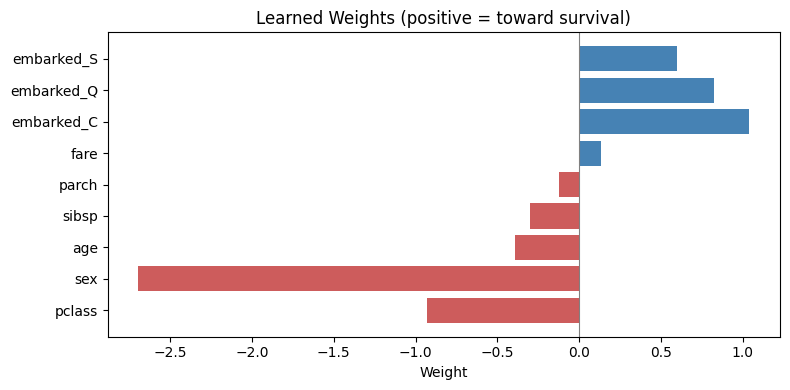

In [10]:
# Visualize the weights
plt.figure(figsize=(8, 4))
colors = ['steelblue' if w > 0 else 'indianred' for w in model.weights]
plt.barh(features, model.weights, color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Learned Weights (positive = toward survival)")
plt.xlabel("Weight")
plt.tight_layout()
plt.show()

### Reading the weights

The model confirms the Day 1 hypothesis from the data exploration:
- **`sex`** has a large negative weight. Since male=1, a strong negative weight means being male sharply *lowers* survival probability — matching P(survived\|female) ≈ 0.74 vs P(survived\|male) ≈ 0.19.
- **`pclass`** has a negative weight: higher class number (3rd vs 1st) lowers survival — matching the class gradient we saw.
- **`fare`** trends positive: wealthier passengers (who paid more) survived more often, correlated with class.

The model learned, automatically and from scratch, the same patterns we computed by hand as conditional probabilities on Day 1.

---

## Summary

| Step | Result |
|---|---|
| Built logistic regression | From scratch, NumPy only |
| Gradient | Used the derived `(p - y)` result |
| Test accuracy | ~0.80 (above 78% target) |
| Interpretability | Weights match the conditional probabilities from Day 1 |

**This completes Phase 1.** From vectors and dot products (Week 1) to a trained classifier on real data that hits its accuracy target and whose learned weights are interpretable — every piece built and understood from the ground up.

**Next: Phase 2 — neural networks and deep learning, starting with a full MLP in NumPy trained on MNIST.**